In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [5]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.resolve()
PROC = PROJECT_ROOT / "data" / "processed"

df = pd.read_csv(PROC / "cleaned_apple_sales_enriched_realistic.csv")

In [6]:
df.head()

,sale_id,sale_date,store_id,product_id,quantity,product_name,launch_date,price,store_name,city,...,promo_factor,price_realistic,days_from_start,product_trend,trend_factor,store_factor,mu_demand,quantity_realistic,sales_amount_realistic,month
0,RW-18212,2020-01-01,ST-41,P-73,2,Apple One,2020-01-01,488,Apple Central World,Bangkok,...,1.0,471.375260,0,0.000783,1.0,1.219421,1.039677,3,1414.125780,1
1,RX-6848,2020-01-01,ST-31,P-40,7,iPhone SE (3rd Generation),2020-01-01,923,Apple Shinjuku,Tokyo,...,1.4,754.811217,0,0.000154,1.0,1.172288,10.813781,6,4528.867303,1
2,SV-39198,2020-01-01,ST-9,P-73,7,Apple One,2020-01-01,488,Apple Park Visitor Center,Cupertino,...,1.0,520.297395,0,0.000783,1.0,0.958735,6.406862,5,2601.486975,1
3,ZI-218670,2020-01-01,ST-20,P-70,1,Apple Fitness+,2020-01-01,923,Apple Kaerntner Strasse,Vienna,...,1.0,986.821602,0,0.000692,1.0,1.109330,0.795094,1,986.821602,1
4,VB-48589,2020-01-01,ST-60,P-18,9,Beats Solo Pro,2020-01-01,1773,Apple Antara,Mexico City,...,1.0,1754.958804,0,0.000495,1.0,1.203289,4.415985,4,7019.835216,1


In [7]:
df["sale_date"] = pd.to_datetime(df["sale_date"])
df["year"] = df["sale_date"].dt.year
df["month"] = df["sale_date"].dt.month

In [8]:
monthly_df = (
    df.groupby(["store_name","year","month"], as_index=False)
    .agg({
        "sales_amount_realistic":"sum",
        "gdp_per_capita":"mean",
        "inflation_rate":"mean",
        "exchange_rate":"mean",
        "internet_usage_pct":"mean"
    })
)

monthly_df = monthly_df.sort_values(["store_name","year","month"]).reset_index(drop=True)

In [9]:
# Store encoding
monthly_df["store_id"] = monthly_df["store_name"].astype("category").cat.codes

# Seasonality
monthly_df["month_sin"] = np.sin(2*np.pi*monthly_df["month"]/12)
monthly_df["month_cos"] = np.cos(2*np.pi*monthly_df["month"]/12)

# Lags
monthly_df["lag_1"] = monthly_df.groupby("store_name")["sales_amount_realistic"].shift(1)
monthly_df["lag_3"] = monthly_df.groupby("store_name")["sales_amount_realistic"].shift(3)
monthly_df["lag_6"] = monthly_df.groupby("store_name")["sales_amount_realistic"].shift(6)
monthly_df["lag_12"] = monthly_df.groupby("store_name")["sales_amount_realistic"].shift(12)

# Rolling
monthly_df["rolling_mean_3"] = monthly_df.groupby("store_name")["sales_amount_realistic"].shift(1).rolling(3).mean()
monthly_df["rolling_mean_6"] = monthly_df.groupby("store_name")["sales_amount_realistic"].shift(1).rolling(6).mean()

# Growth indicators
monthly_df["yoy_growth"] = (monthly_df["sales_amount_realistic"] - monthly_df["lag_12"]) / monthly_df["lag_12"]
monthly_df["sales_momentum"] = monthly_df["lag_1"] - monthly_df["lag_3"]

# Season strength
monthly_avg = monthly_df.groupby("month")["sales_amount_realistic"].transform("mean")
monthly_df["season_strength"] = monthly_df["sales_amount_realistic"] / monthly_avg

# Economic changes
monthly_df["gdp_growth"] = monthly_df["gdp_per_capita"].pct_change()
monthly_df["inflation_change"] = monthly_df["inflation_rate"].pct_change()
monthly_df["exchange_change"] = monthly_df["exchange_rate"].pct_change()
monthly_df["internet_growth"] = monthly_df["internet_usage_pct"].pct_change()

# Interaction
monthly_df["gdp_sales_effect"] = monthly_df["gdp_growth"] * monthly_df["lag_1"]

monthly_df = monthly_df.dropna().reset_index(drop=True)

In [10]:
feature_cols = [

"store_id",
"month_sin","month_cos",
"lag_1","lag_3","lag_6","lag_12",
"rolling_mean_3","rolling_mean_6",
"yoy_growth","sales_momentum","season_strength",
"gdp_growth","inflation_change","exchange_change","internet_growth",
"gdp_sales_effect"

]

target_col = "sales_amount_realistic"

In [11]:
X = monthly_df[feature_cols]
y = monthly_df[target_col]

X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_scaled = X_scaler.fit_transform(X)
y_scaled = y_scaler.fit_transform(y.values.reshape(-1,1))

In [12]:
def create_sequences(X, y, window):

    X_seq=[]
    y_seq=[]

    for i in range(len(X)-window):
        X_seq.append(X[i:i+window])
        y_seq.append(y[i+window])

    return np.array(X_seq), np.array(y_seq)

window_size = 12

X_seq, y_seq = create_sequences(X_scaled, y_scaled.flatten(), window_size)

print(X_seq.shape)

(3231, 12, 17)


In [13]:
split = int(len(X_seq)*0.8)

X_train = X_seq[:split]
X_test = X_seq[split:]

y_train = y_seq[:split]
y_test = y_seq[split:]

In [14]:
model = Sequential([

    LSTM(128, return_sequences=True, input_shape=(window_size, X_seq.shape[2])),

    Dropout(0.2),

    LSTM(64),

    Dense(1)

])

model.compile(optimizer="adam", loss="mse")

d:\anaconda\envs\Apple\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [15]:
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(

    X_train,
    y_train,

    validation_data=(X_test,y_test),

    epochs=100,
    batch_size=32,

    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.3346 - val_loss: 0.2714
Epoch 2/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2410 - val_loss: 0.2137
Epoch 3/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2105 - val_loss: 0.2266
Epoch 4/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2019 - val_loss: 0.1562
Epoch 5/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1504 - val_loss: 0.1487
Epoch 6/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1367 - val_loss: 0.1412
Epoch 7/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1083 - val_loss: 0.1278
Epoch 8/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1059 - val_loss: 0.1243
Epoch 9/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0977 - val_loss: 0.1274
Epoch 10/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0906 - val_loss: 0.1147
Epoch 11/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0872 - val_loss: 0.1022
Epoch 12/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.

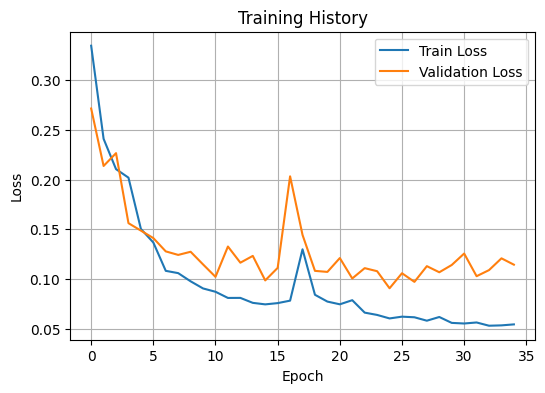

In [16]:
plt.figure(figsize=(6,4))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid()

plt.show()

In [17]:
pred_scaled = model.predict(X_test)

pred = y_scaler.inverse_transform(pred_scaled)

y_true = y_scaler.inverse_transform(y_test.reshape(-1,1))

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [18]:
y_pred = pred.flatten()
y_true = y_true.flatten()

mae = mean_absolute_error(y_true,y_pred)
rmse = np.sqrt(mean_squared_error(y_true,y_pred))
mape = np.mean(np.abs((y_true-y_pred)/np.maximum(y_true,1)))*100
r2 = r2_score(y_true,y_pred)

print("MAE:",mae)
print("RMSE:",rmse)
print("MAPE:",mape)
print("R2:",r2)

MAE: 186002.49432348667
RMSE: 252561.00759377872
MAPE: 12.48363068123975
R2: 0.9231596583697275


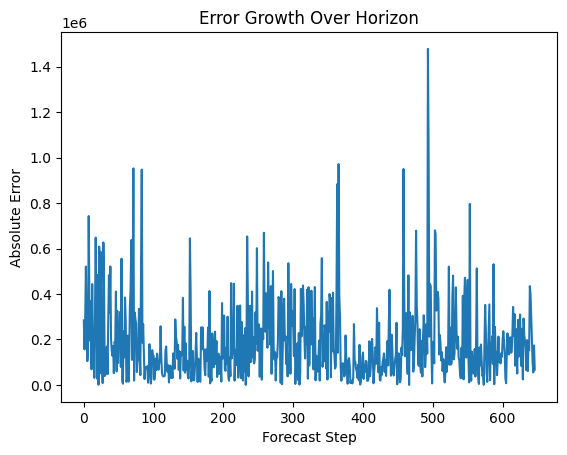

In [19]:
errors = np.abs(y_true-y_pred)

plt.plot(errors)
plt.title("Error Growth Over Horizon")
plt.xlabel("Forecast Step")
plt.ylabel("Absolute Error")
plt.show()

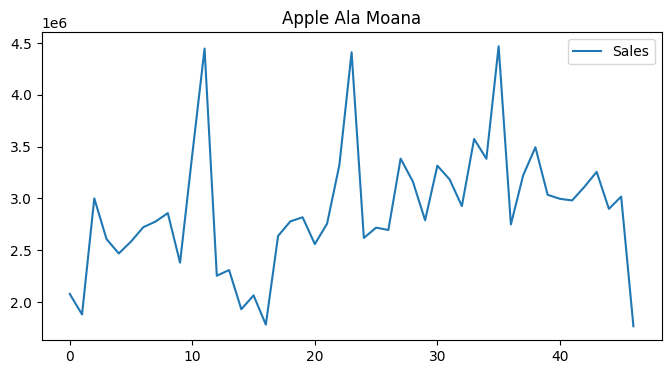

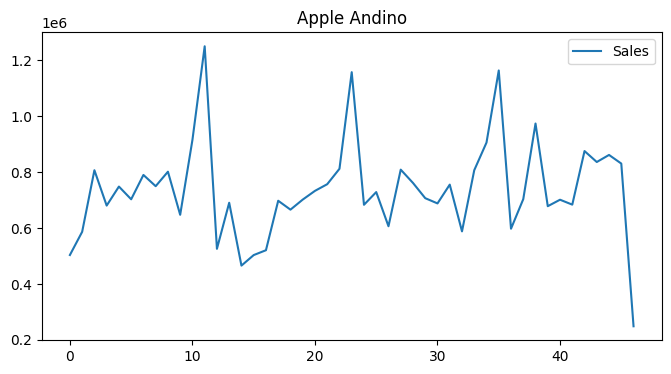

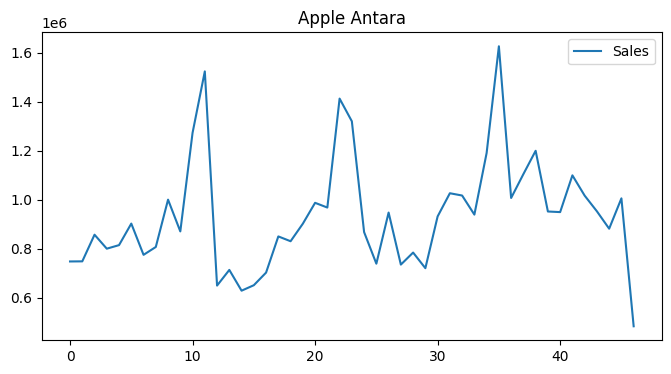

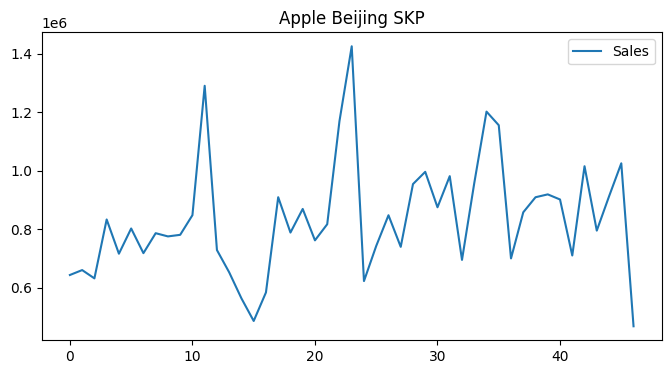

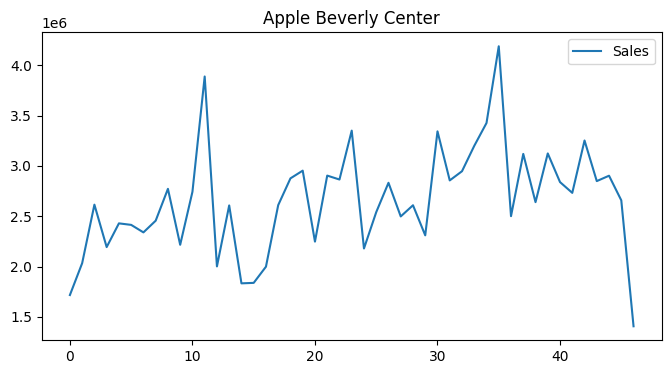

In [20]:
for store in monthly_df["store_name"].unique()[:5]:

    store_data = monthly_df[monthly_df["store_name"]==store]

    plt.figure(figsize=(8,4))

    plt.plot(store_data[target_col].values,label="Sales")

    plt.title(store)
    plt.legend()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


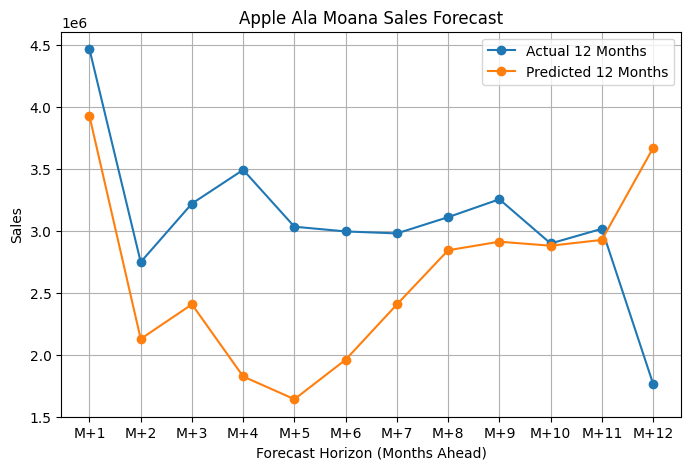

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


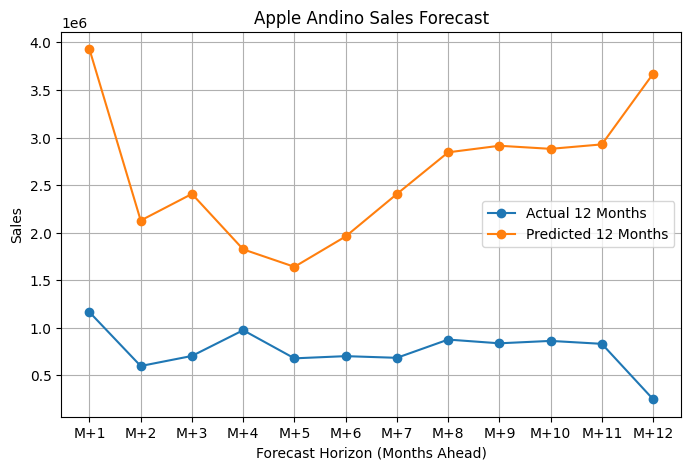

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


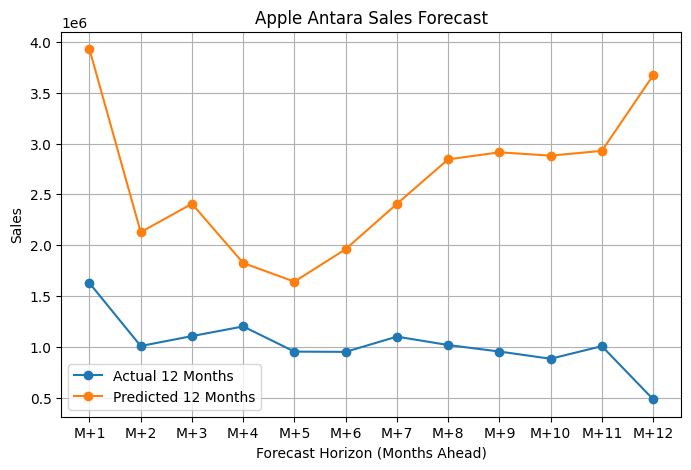

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


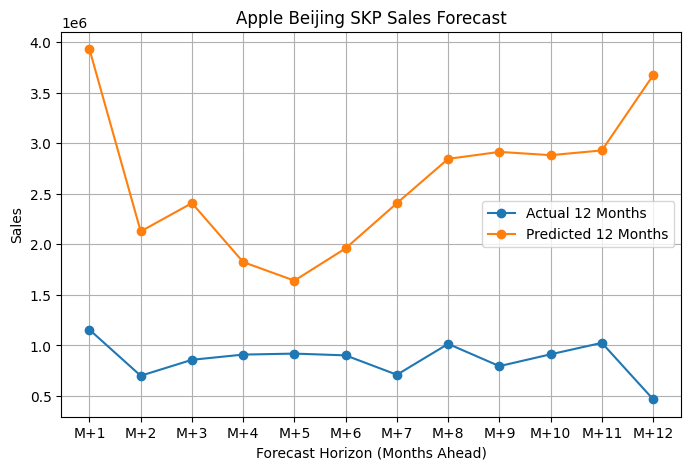

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


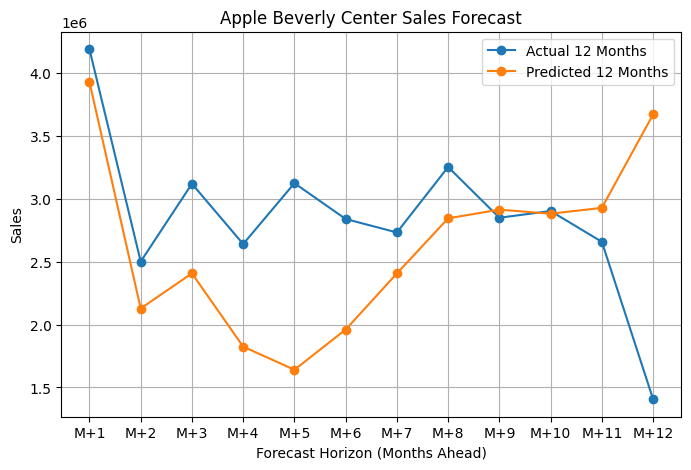

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


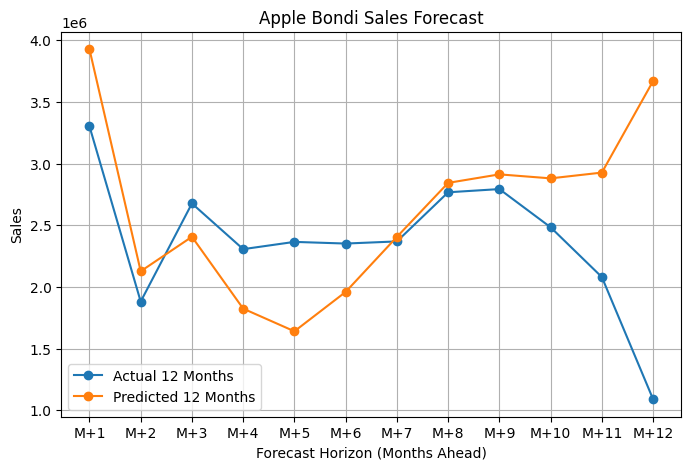

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


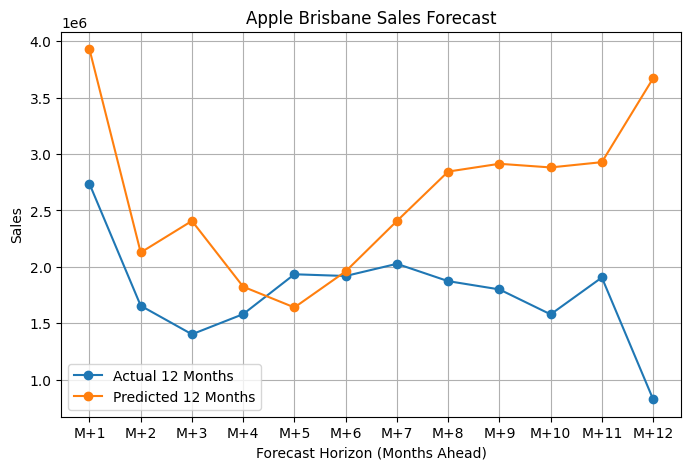

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


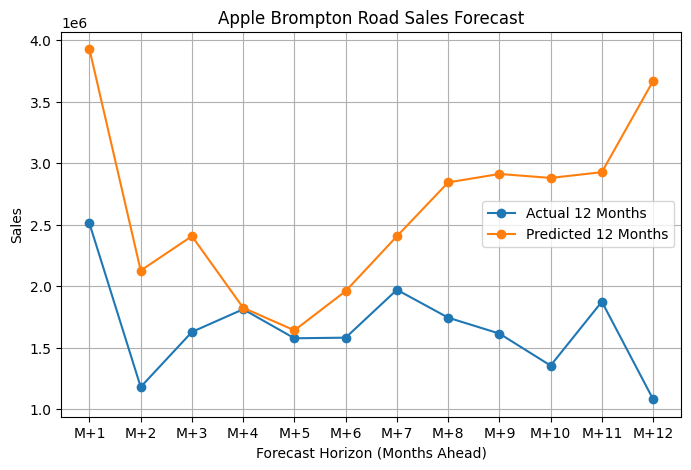

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


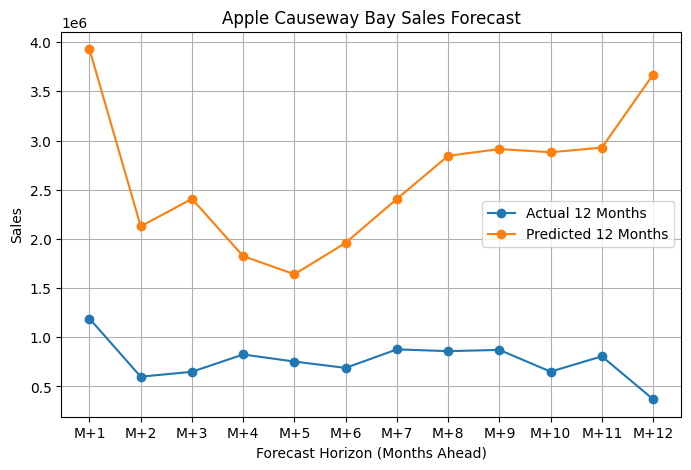

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


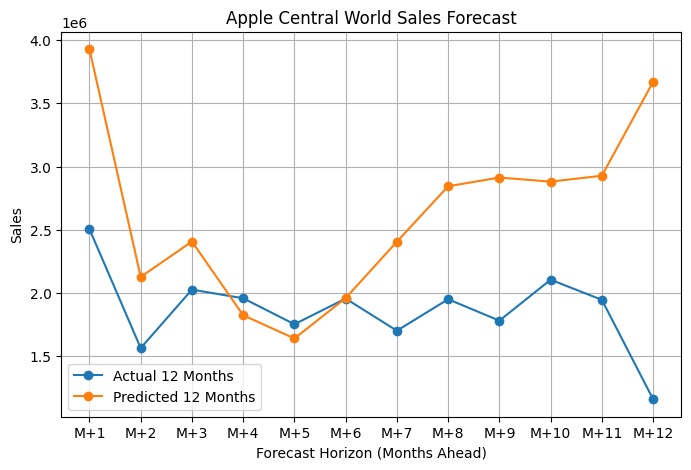

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


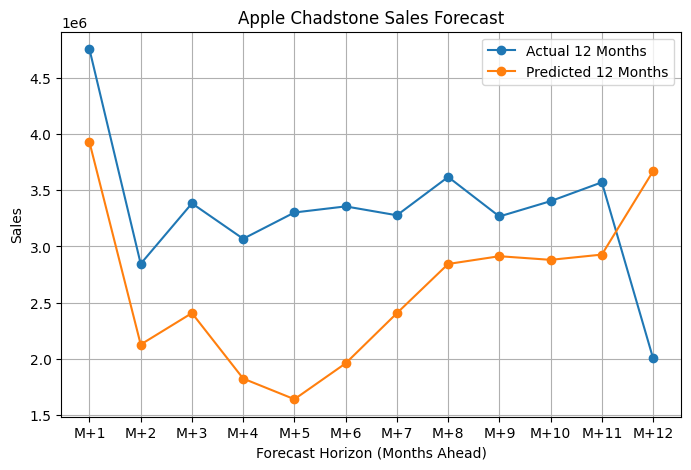

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


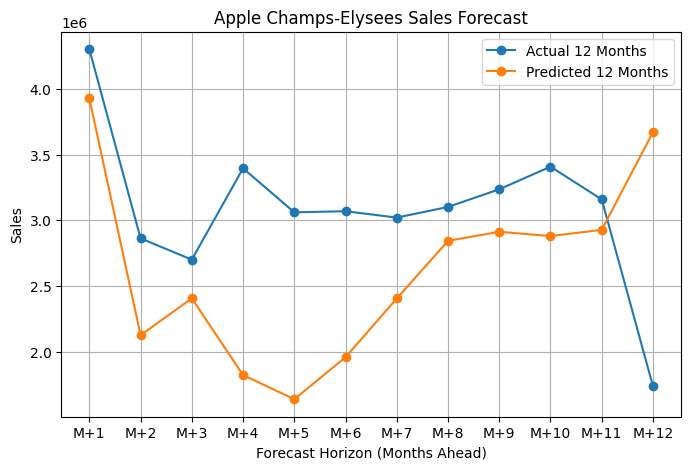

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


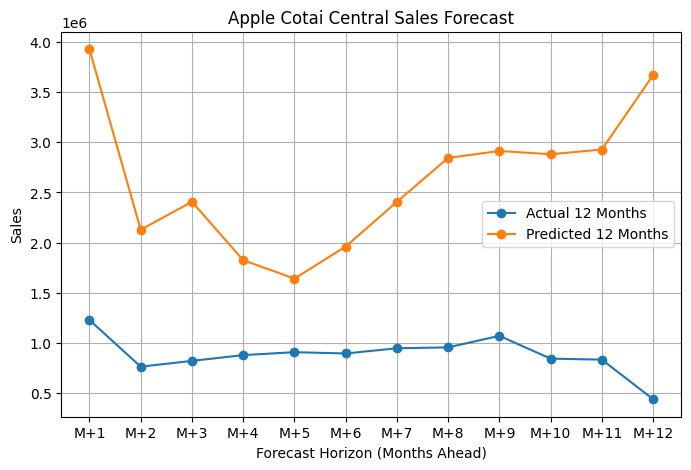

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


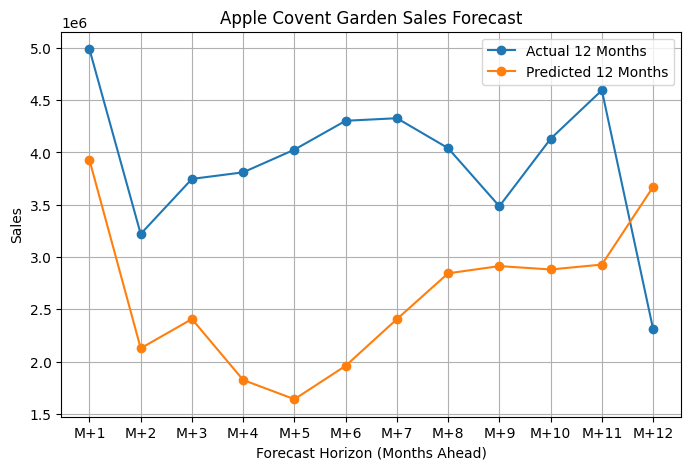

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


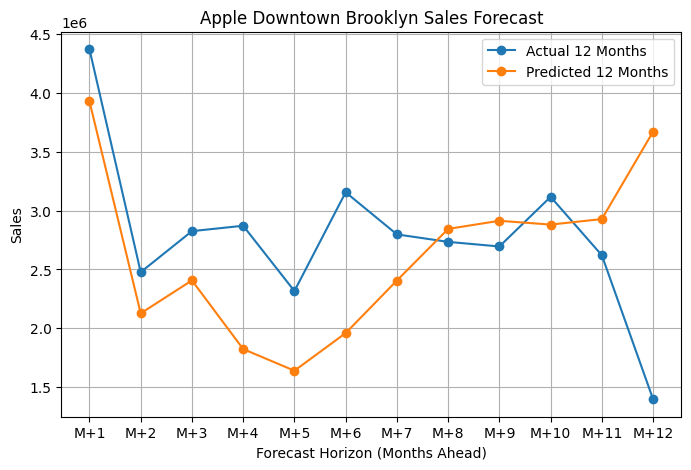

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


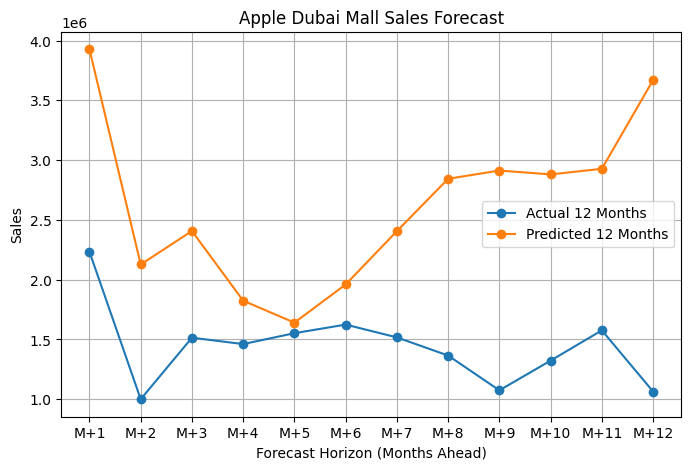

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


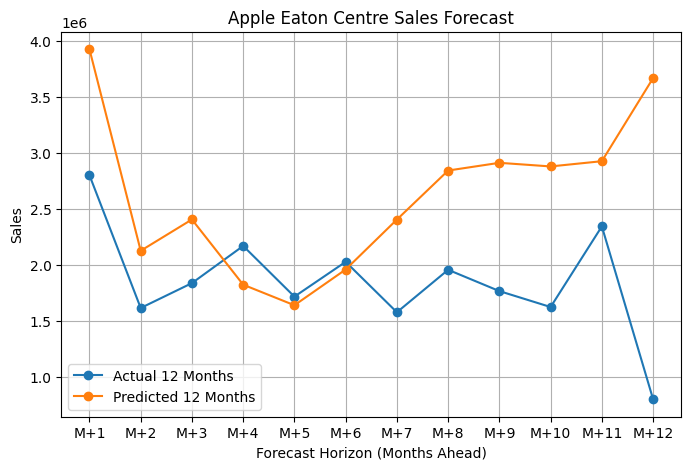

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


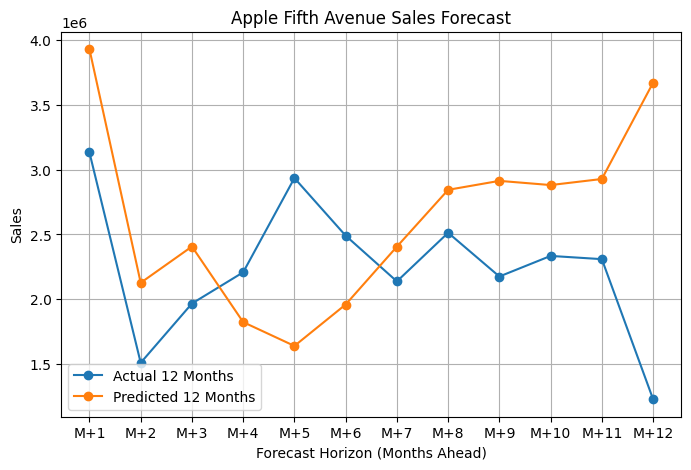

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


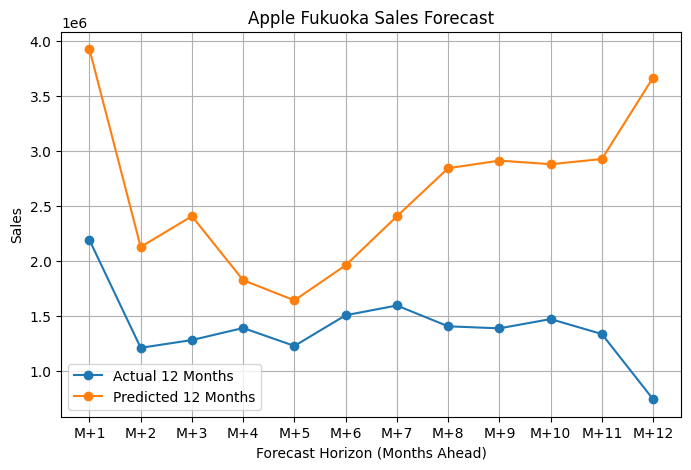

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


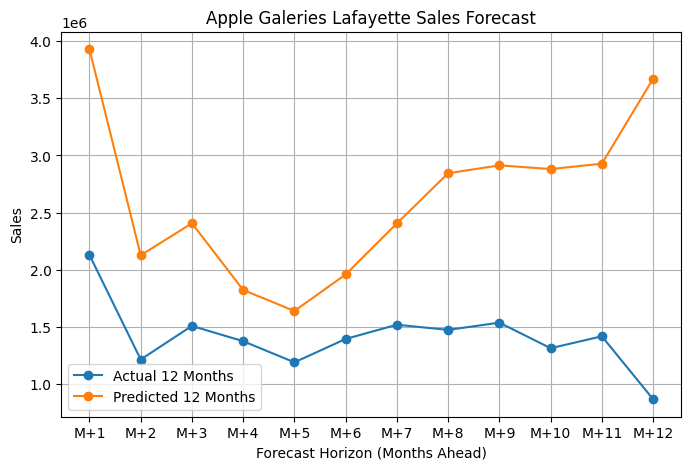

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


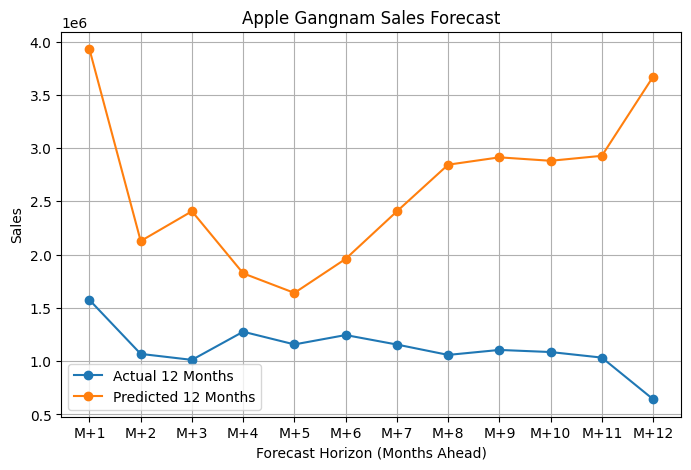

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


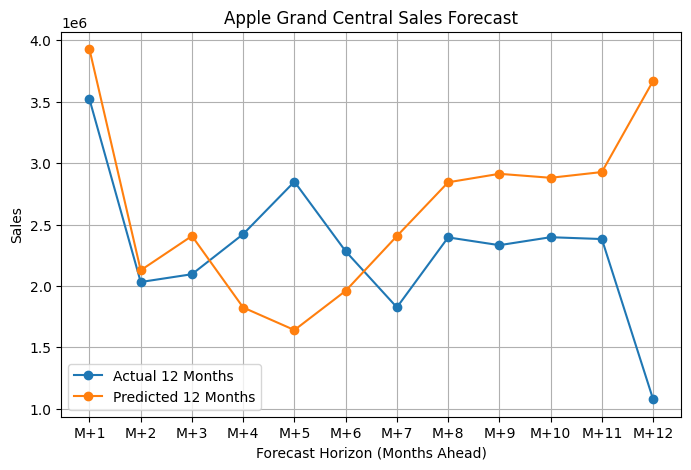

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


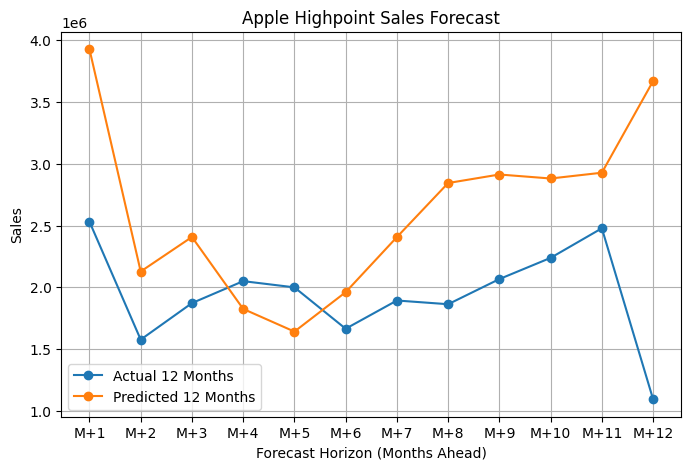

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


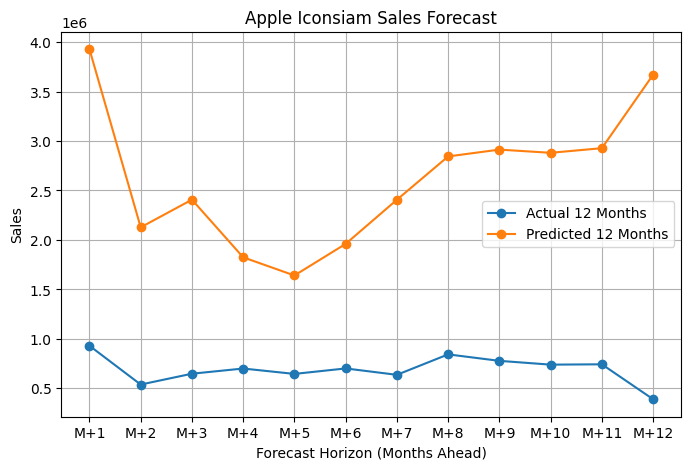

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


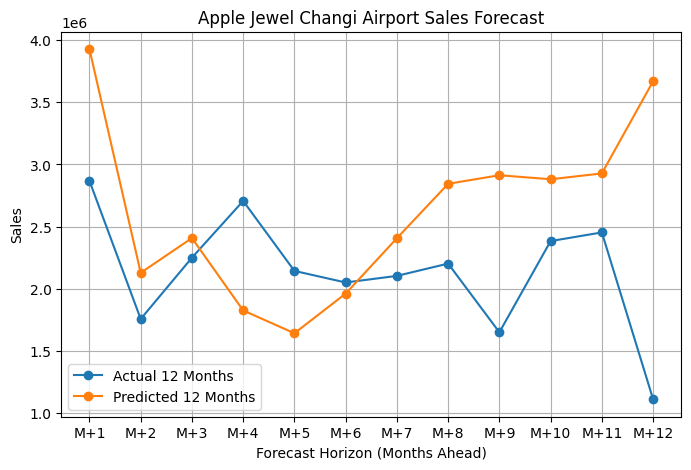

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


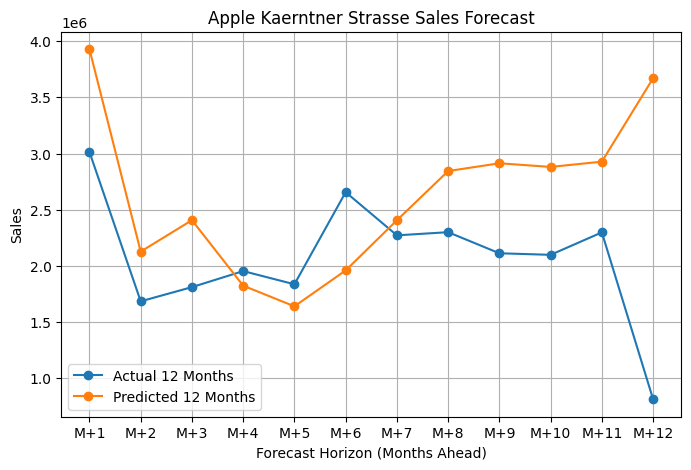

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


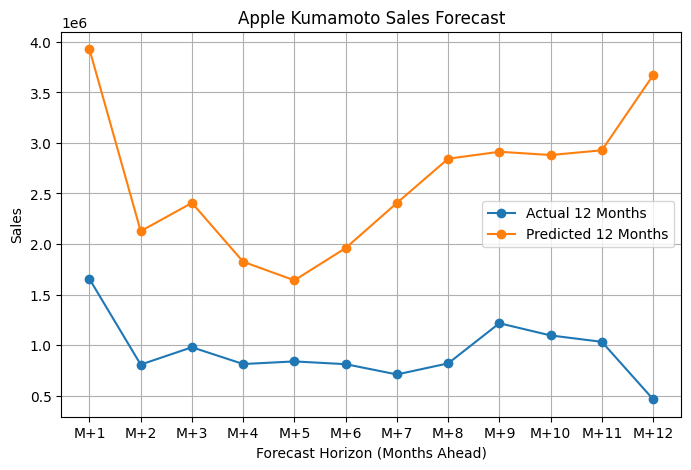

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


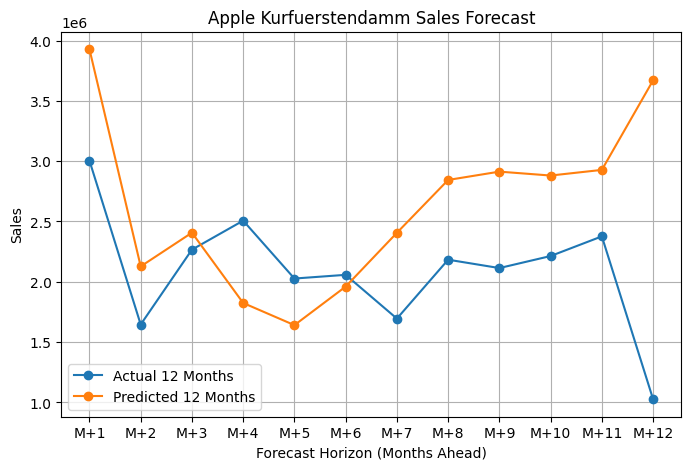

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


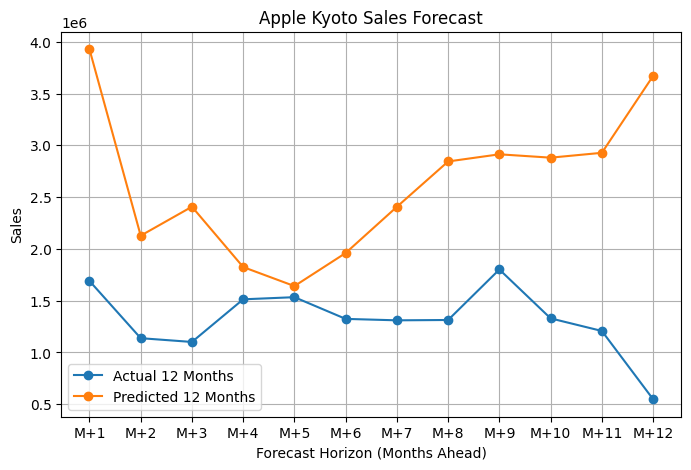

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


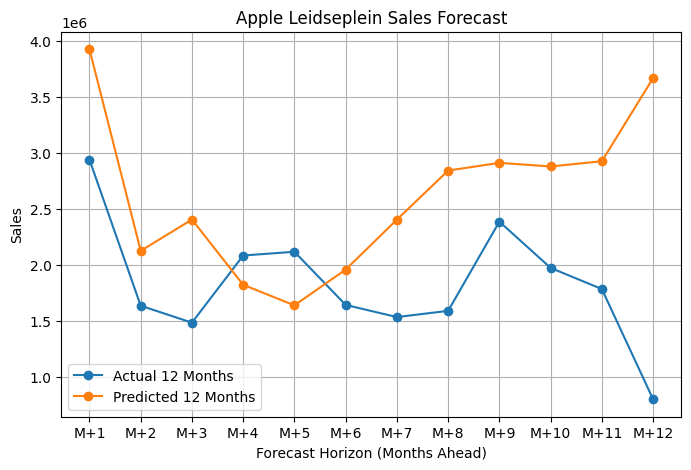

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


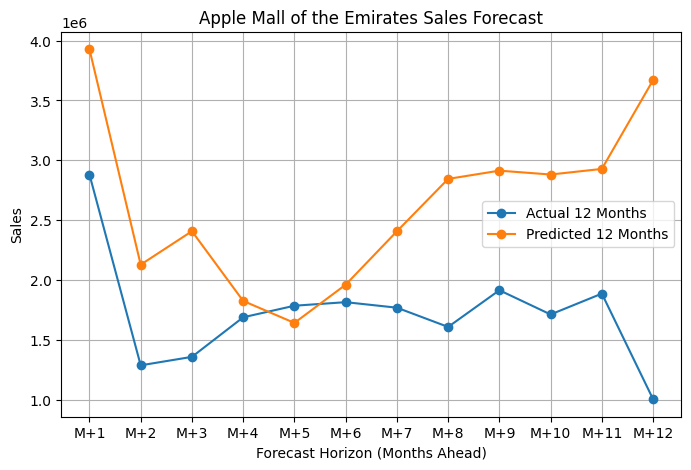

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


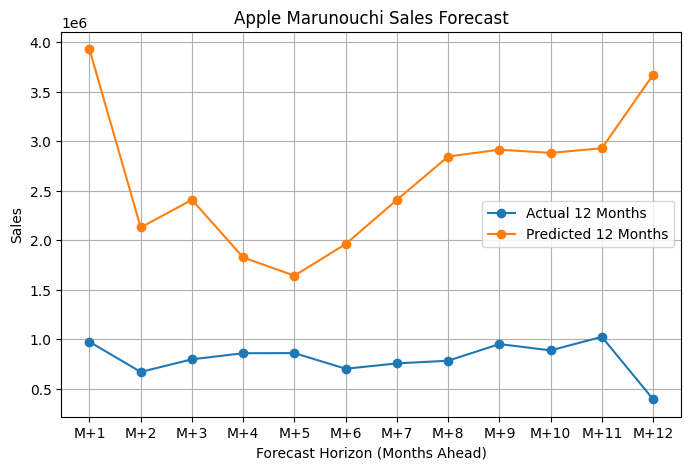

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


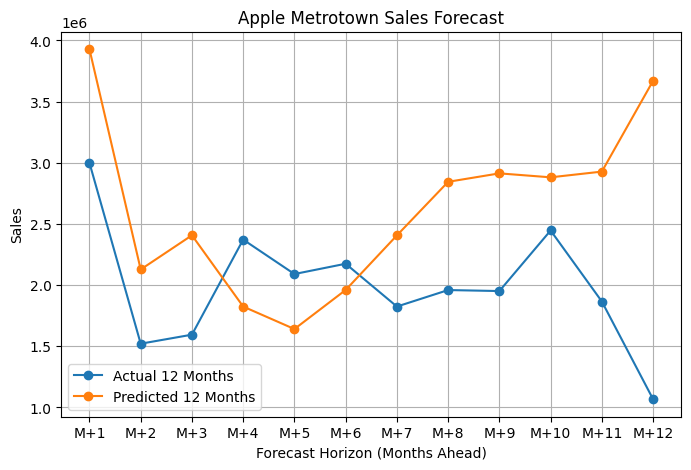

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


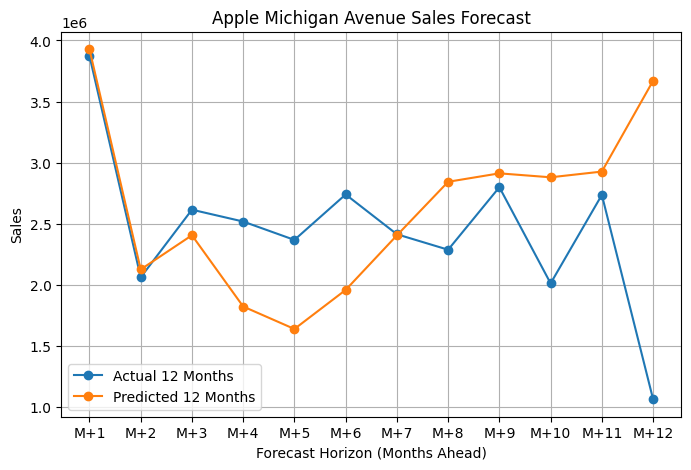

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


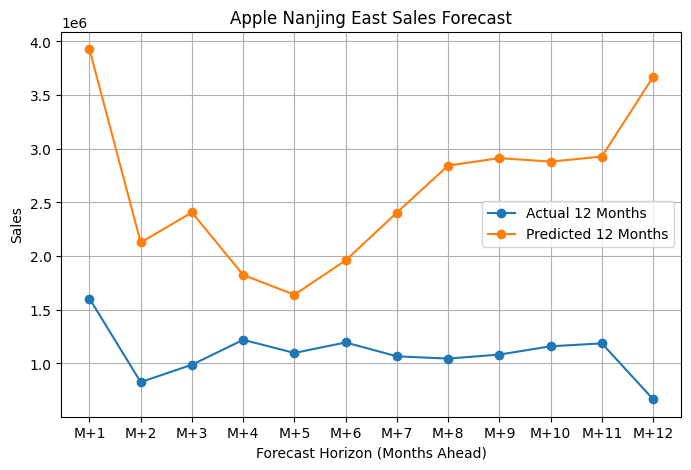

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


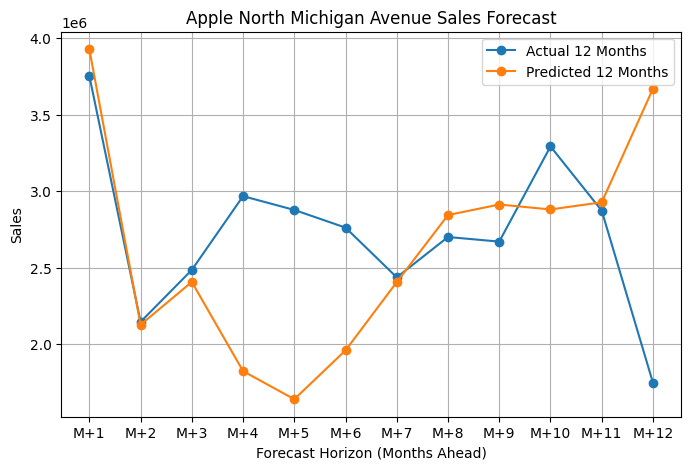

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


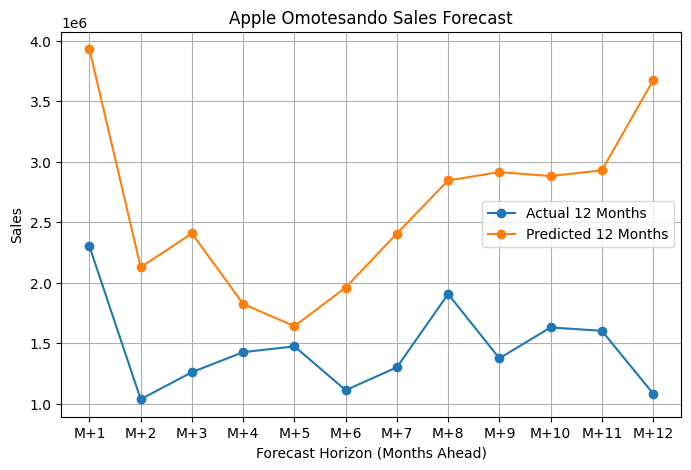

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


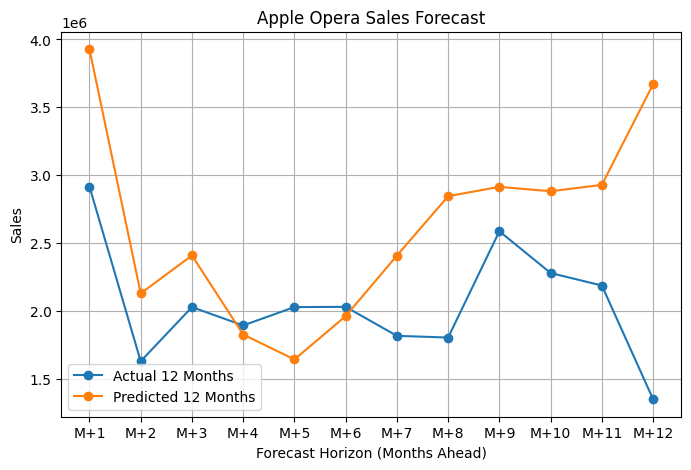

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


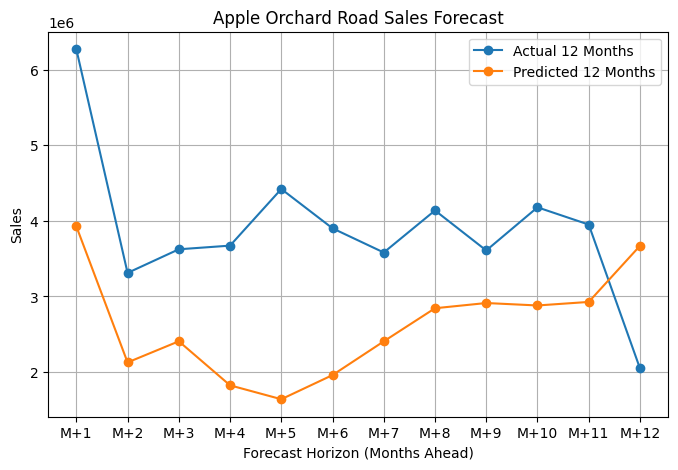

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


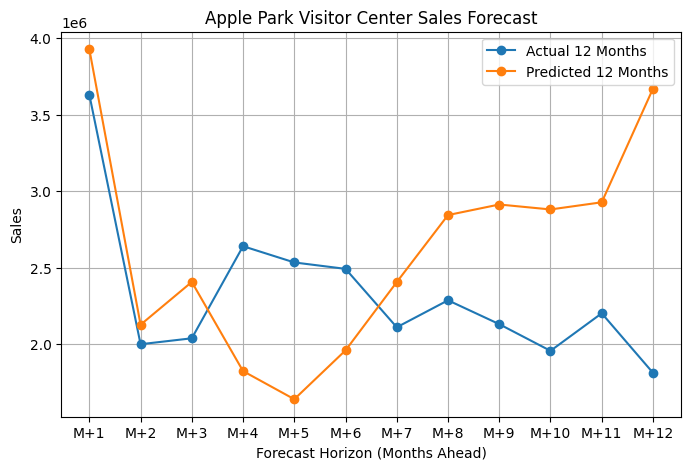

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


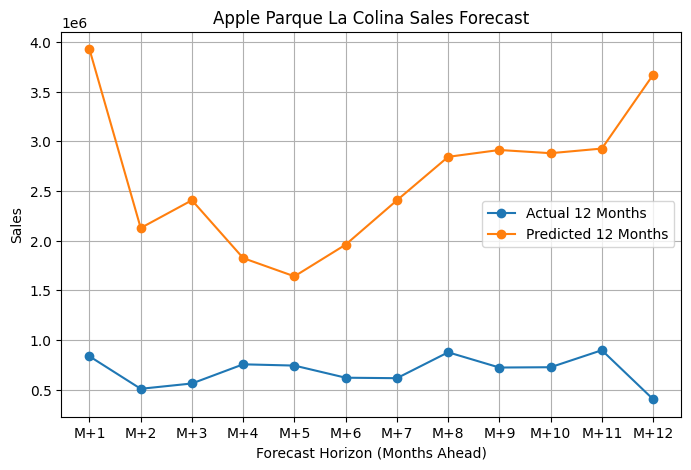

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


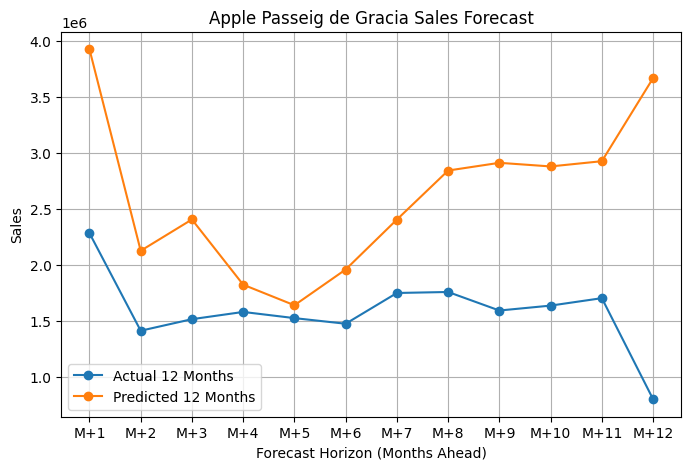

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


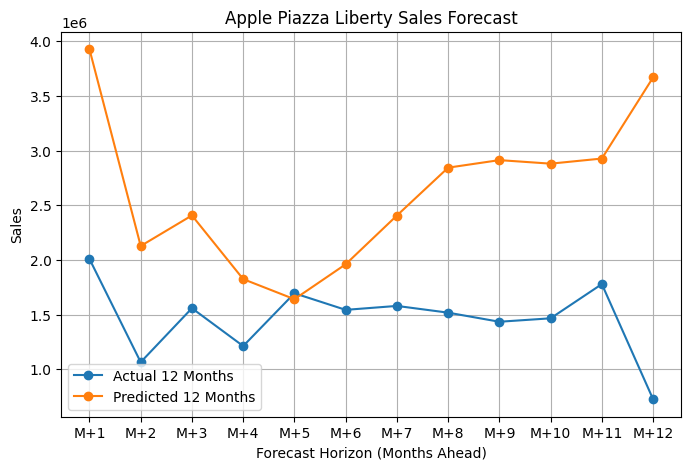

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


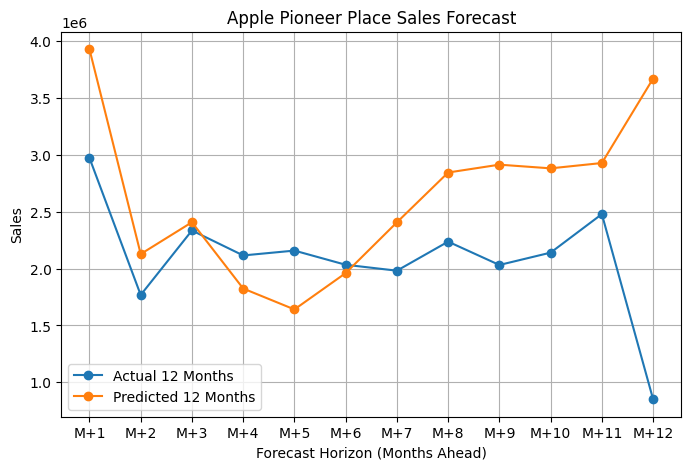

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


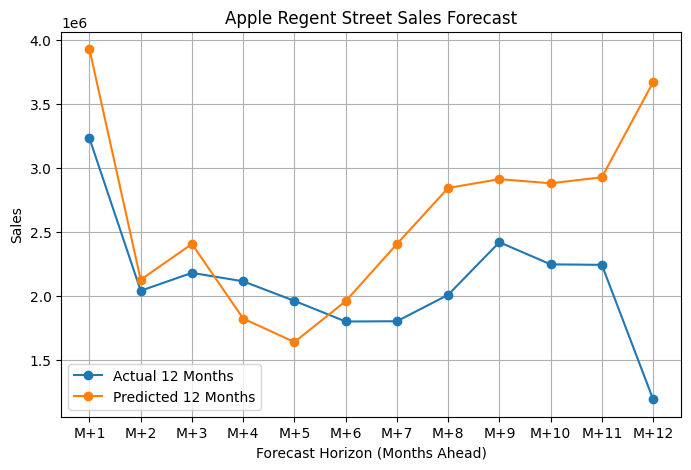

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


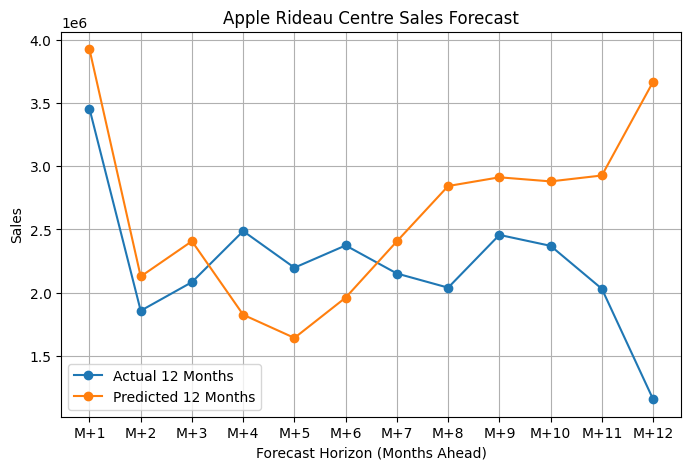

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


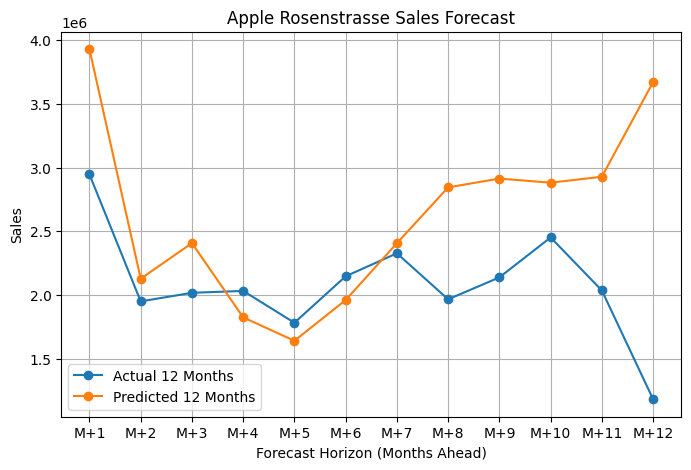

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


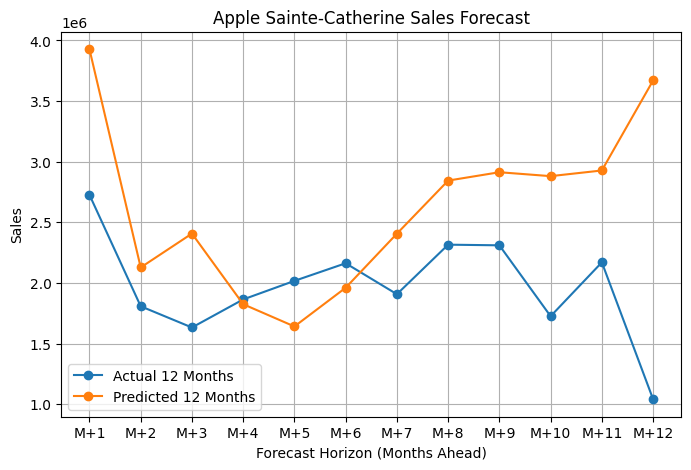

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


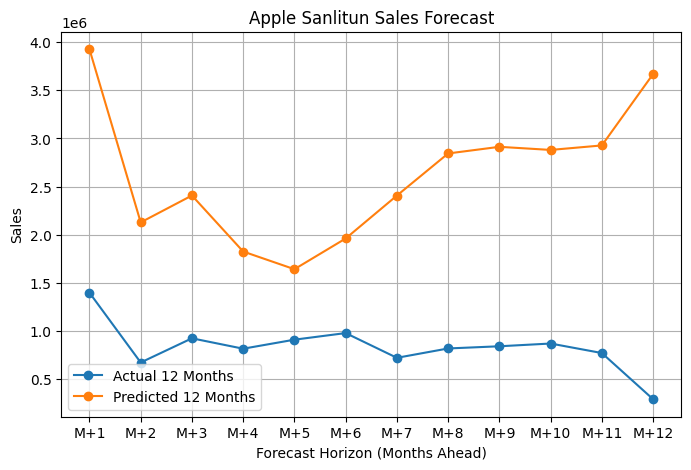

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


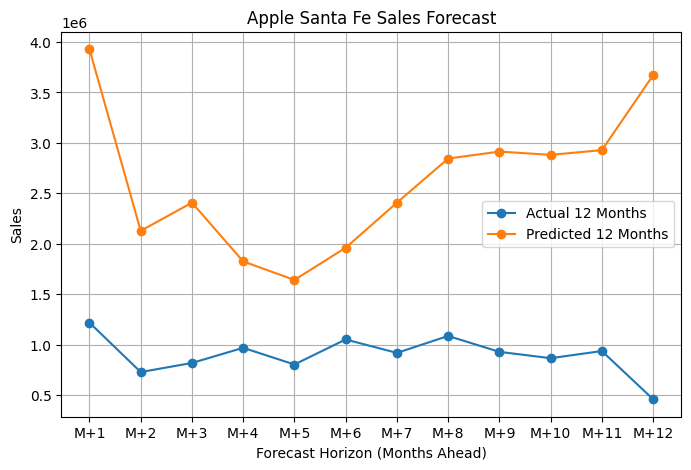

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


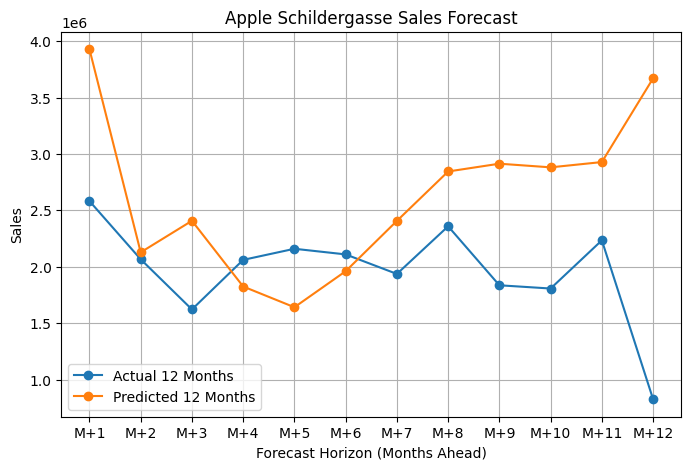

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


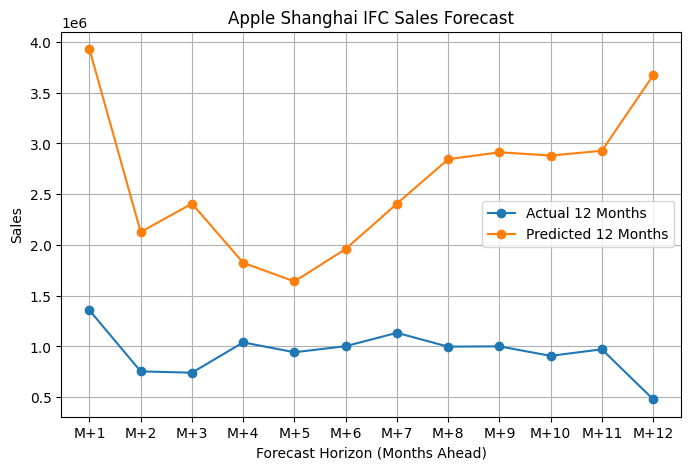

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


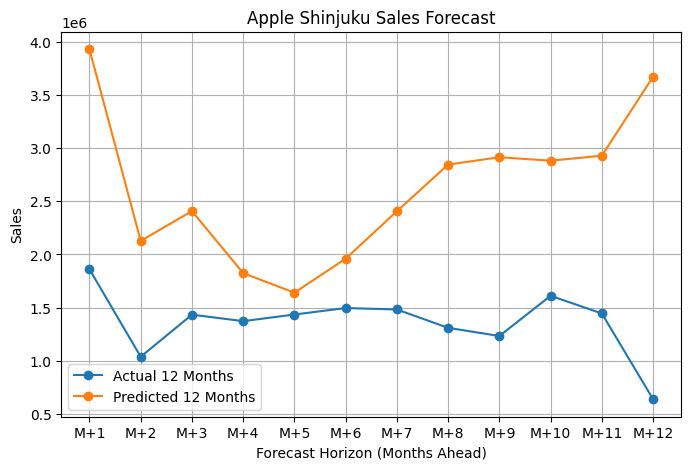

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


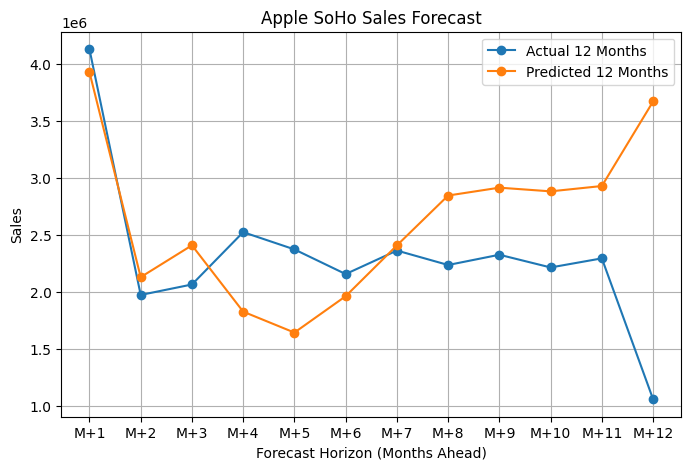

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


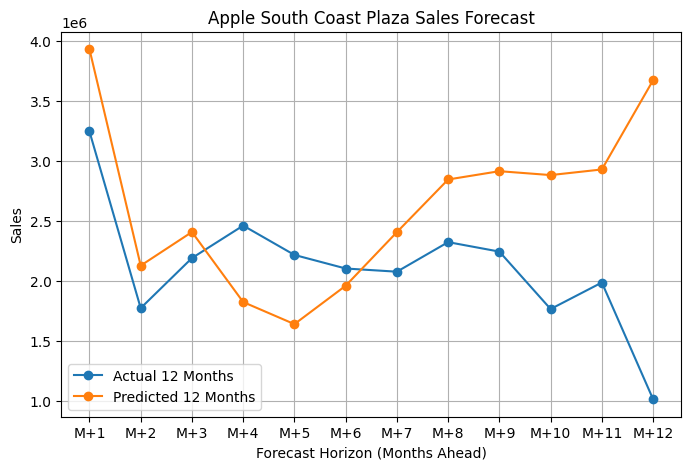

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


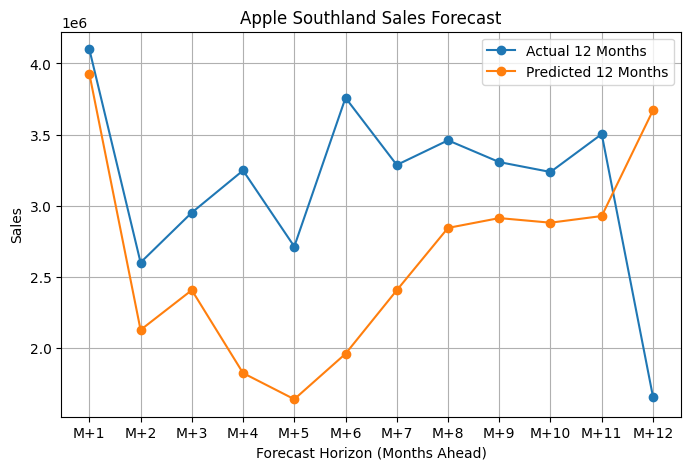

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


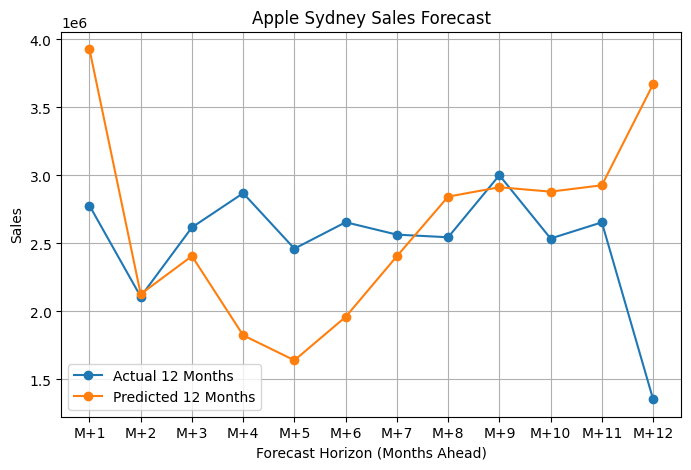

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


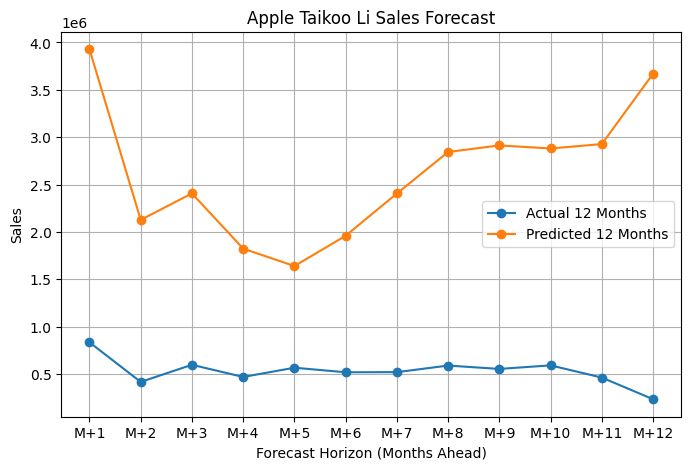

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


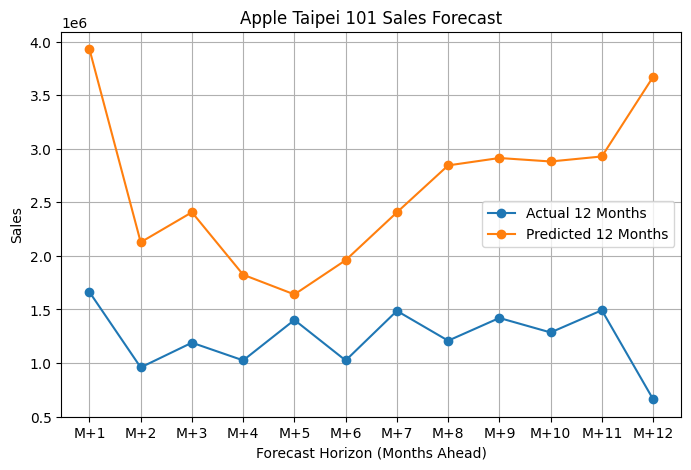

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


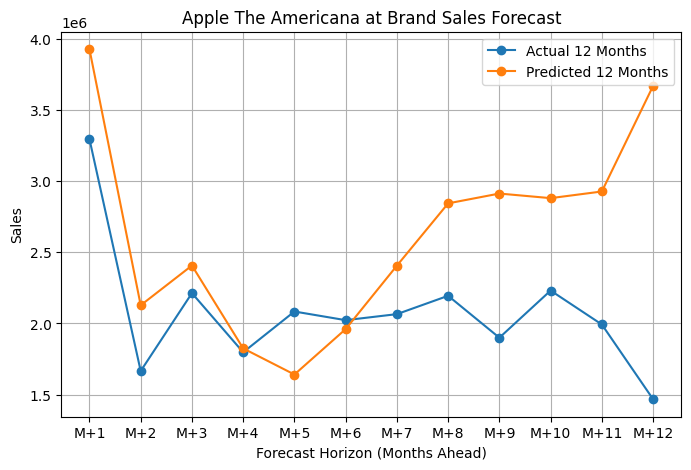

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


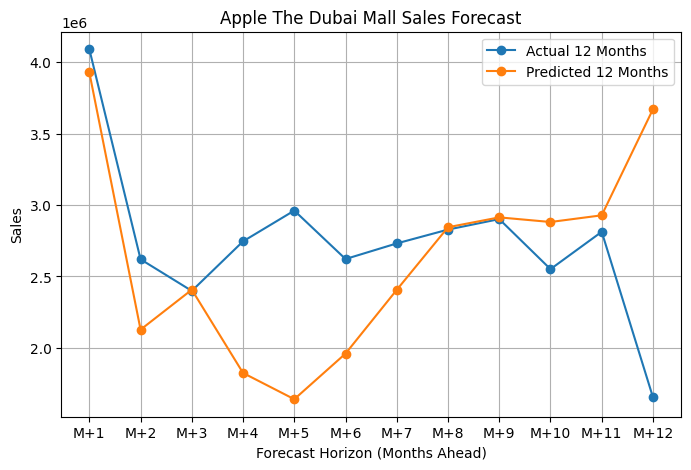

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


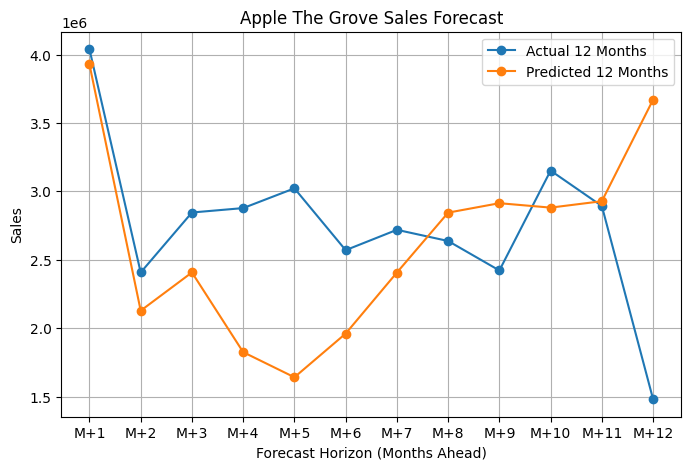

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


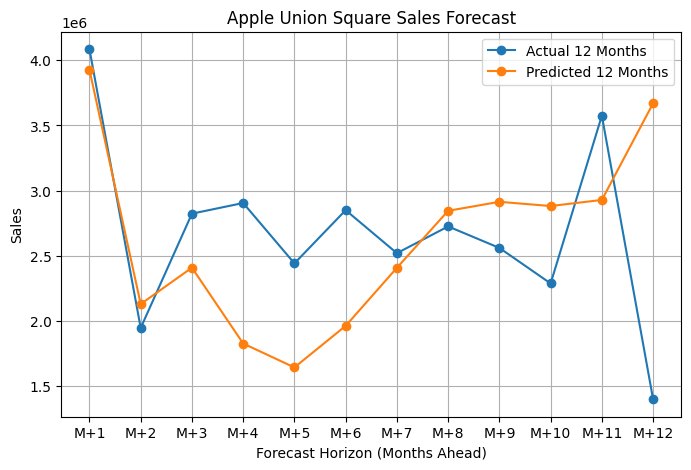

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


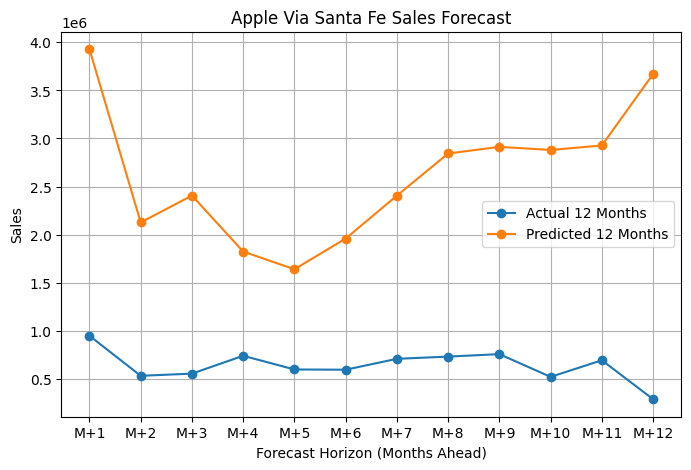

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


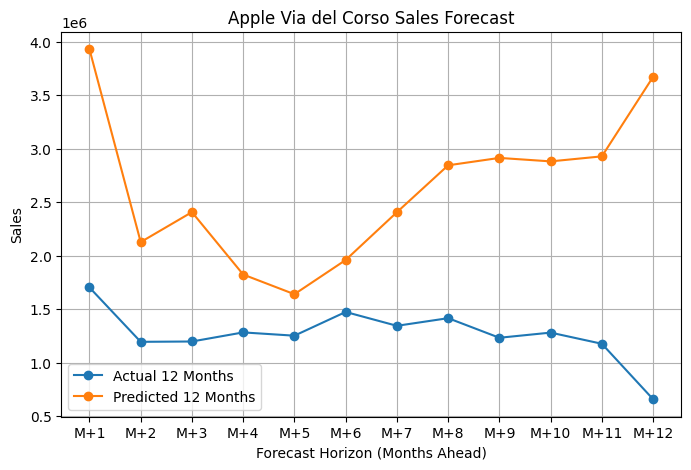

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


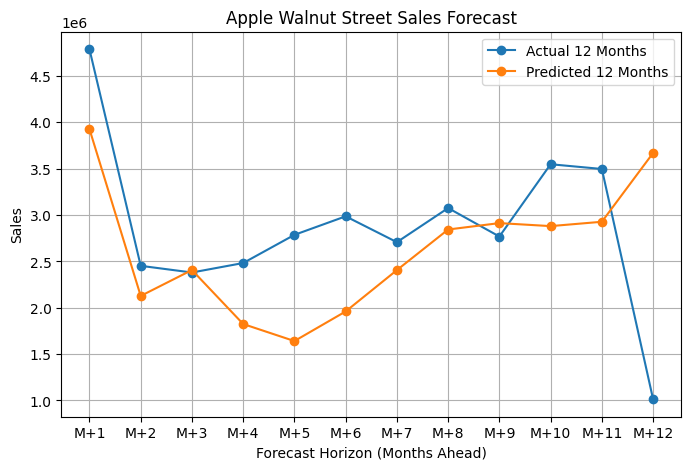

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


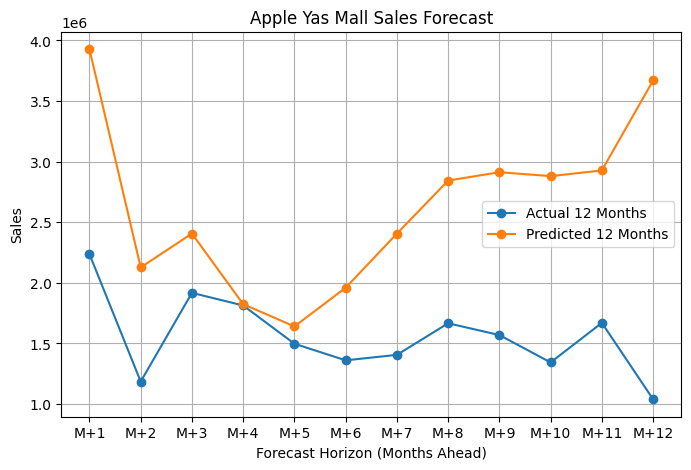

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


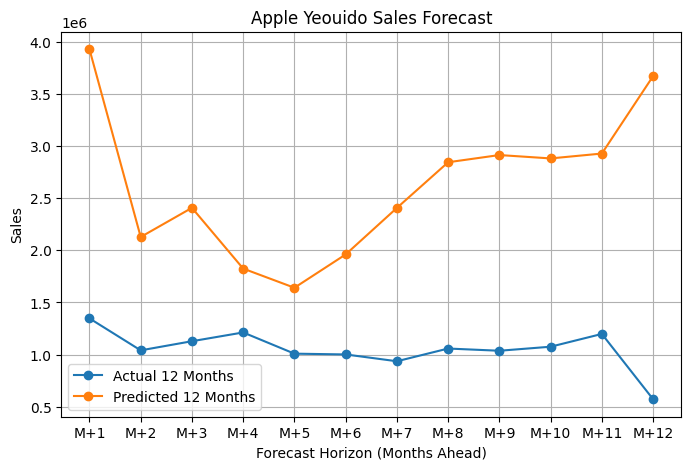

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


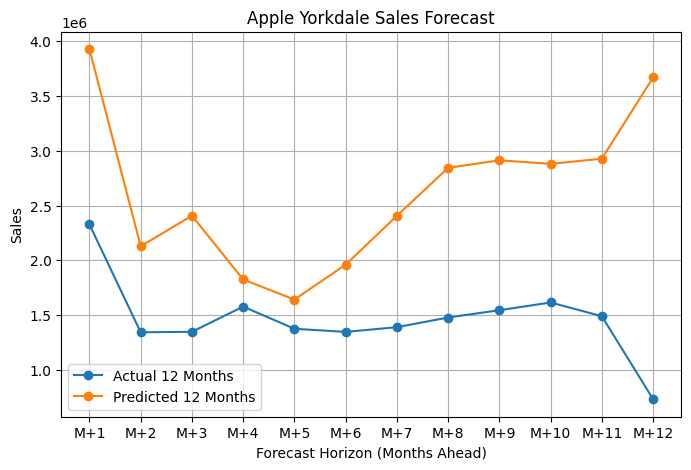

In [21]:
stores = monthly_df["store_name"].unique()

for store in stores:

    store_data = monthly_df[monthly_df["store_name"] == store]

    # last 12 actual values
    actual = store_data[target_col].values[-12:]

    # predicted values (replace with your predictions if stored differently)
    predicted = model.predict(X_test[:12])
    predicted = y_scaler.inverse_transform(predicted).flatten()

    months = [f"M+{i}" for i in range(1,13)]

    plt.figure(figsize=(8,5))

    plt.plot(months, actual,
             marker='o',
             label="Actual 12 Months")

    plt.plot(months, predicted,
             marker='o',
             label="Predicted 12 Months")

    plt.title(f"{store} Sales Forecast")

    plt.xlabel("Forecast Horizon (Months Ahead)")
    plt.ylabel("Sales")

    plt.legend()
    plt.grid(True)

    plt.show()

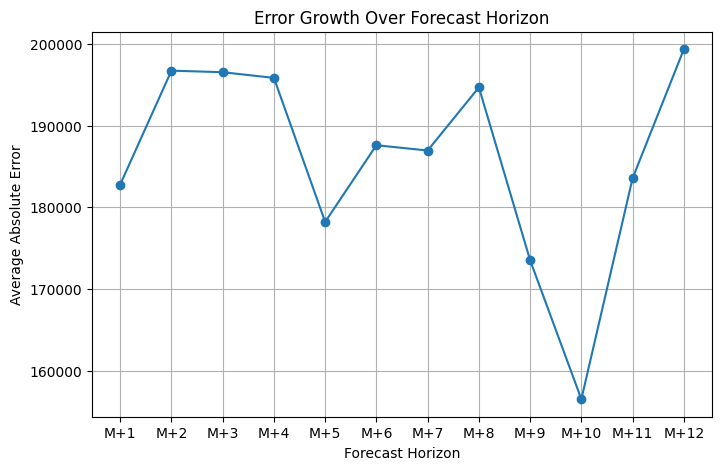

In [22]:
errors = np.abs(y_true - y_pred)

horizon_errors = []

for h in range(12):

    horizon_errors.append(np.mean(errors[h::12]))

months = [f"M+{i}" for i in range(1,13)]

plt.figure(figsize=(8,5))

plt.plot(months, horizon_errors, marker="o")

plt.title("Error Growth Over Forecast Horizon")

plt.xlabel("Forecast Horizon")
plt.ylabel("Average Absolute Error")

plt.grid()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━

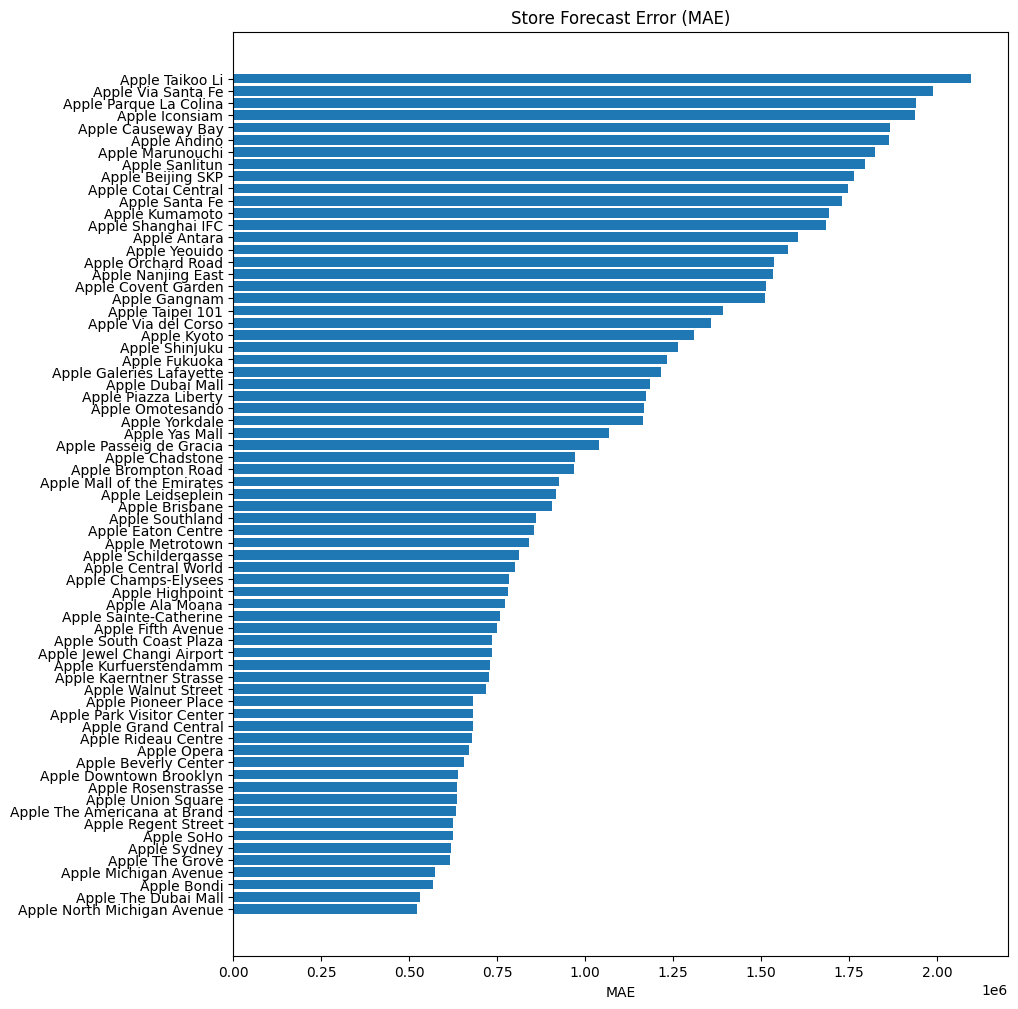

In [23]:
store_errors = []

stores = monthly_df["store_name"].unique()

for store in stores:

    store_data = monthly_df[monthly_df["store_name"] == store]

    actual = store_data[target_col].values[-12:]

    pred_scaled = model.predict(X_test[:12])
    predicted = y_scaler.inverse_transform(pred_scaled).flatten()

    mae = mean_absolute_error(actual, predicted)

    store_errors.append(mae)

error_df = pd.DataFrame({
    "store": stores,
    "MAE": store_errors
}).sort_values("MAE")

plt.figure(figsize=(10,12))

plt.barh(error_df["store"], error_df["MAE"])

plt.title("Store Forecast Error (MAE)")
plt.xlabel("MAE")

plt.show()